# Spotify Playlist Success: Segmented Descriptive Analysis

This notebook follows a deliberately cautious analysis plan for the playlist assignment.

## Working framing
- The data are **cross-sectional**, so this notebook does **not** make causal claims.
- The sample mixes at least two playlist ecosystems:
  - `Spotify-owned playlists`
  - `user-owned playlists`
- Because those groups likely have different goals and exposure mechanisms, the main feature-success analysis focuses on **user-owned playlists**.

## Main analytical choices
- Use a **platform-facing** success metric:
  - `non_owner_monthly_stream30s = monthly_stream30s - monthly_owner_stream30s`
- Keep the core analysis **continuous**:
  - model `log1p(non_owner_monthly_stream30s)` rather than only labeling "winners"
- Use playlist **structure and content** as the main explanatory features.
- Treat top-decile comparisons as a **communication device**, not the main inferential method.

## Notebook roadmap
1. Setup
2. Load and minimally clean the data
3. Show why pooled analysis is misleading
4. Describe user-owned playlist archetypes (descriptively only)
5. Define success and inspect the user-owned outcome
6. Screen structural correlates of success
7. Add content summaries and multivariable models
8. Use a top-decile view as a secondary communication layer
9. Contrast Spotify-owned playlists and summarize limitations


## 1. Setup

Import libraries, set notebook display options, and define helper functions used later in the analysis.


In [20]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

def resolve_data_path():
    """Allow the notebook to run either from this folder or from the repo root."""
    candidates = [
        Path("playlist_revision_v05.txt"),
        Path("interview_prep/data_science_assignment/playlist_revision_v05.txt"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find playlist_revision_v05.txt")

def screen_spearman(data, target, features):
    """Compute Spearman rho, raw p-values, and BH-adjusted p-values."""
    rows = []
    for feature in features:
        sub = data[[feature, target]].dropna()
        if len(sub) == 0 or sub[feature].nunique() < 2 or sub[target].nunique() < 2:
            rows.append(
                {
                    "feature": feature,
                    "spearman_rho": np.nan,
                    "p_value": np.nan,
                    "n": len(sub),
                }
            )
            continue

        rho, p_value = spearmanr(sub[feature], sub[target])
        rows.append(
            {
                "feature": feature,
                "spearman_rho": rho,
                "p_value": p_value,
                "n": len(sub),
            }
        )

    out = pd.DataFrame(rows)
    out["p_adj_bh"] = np.nan
    valid = out["p_value"].notna()
    if valid.any():
        out.loc[valid, "p_adj_bh"] = multipletests(out.loc[valid, "p_value"], method="fdr_bh")[1]
    out["significant_bh_5pct"] = out["p_adj_bh"] < 0.05
    return out.sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)

def concentration_table(data, value_col, thresholds=(0.5, 0.8, 0.9, 0.95), spotify_col="is_spotify_owned"):
    """How many playlists account for each cumulative share of listening?"""
    ordered = data.sort_values(value_col, ascending=False).reset_index(drop=True)
    total_value = ordered[value_col].sum()
    spotify_total = int(ordered[spotify_col].sum())

    if total_value == 0:
        return pd.DataFrame()

    cumulative_share = ordered[value_col].cumsum() / total_value
    rows = []
    for threshold in thresholds:
        top_n = int((cumulative_share < threshold).sum() + 1)
        top_slice = ordered.iloc[:top_n]
        top_spotify = int(top_slice[spotify_col].sum())
        rows.append(
            {
                "stream_share": f"Top {int(threshold * 100)}% of {value_col}",
                "n_playlists": top_n,
                "pct_of_all_playlists": top_n / len(ordered),
                "n_spotify_owned": top_spotify,
                "pct_of_top_that_is_spotify": top_spotify / top_n if top_n else np.nan,
                "pct_of_all_spotify_playlists": top_spotify / spotify_total if spotify_total else np.nan,
            }
        )
    return pd.DataFrame(rows)

def top_category_group(series, top_n=10):
    """Keep only the most common categories; collapse the rest into Other."""
    top_categories = series.value_counts(dropna=True).head(top_n).index
    return np.where(series.isin(top_categories), series, "Other")

def coefficient_table(model):
    """Collect coefficient estimates and BH-adjusted p-values."""
    out = pd.DataFrame(
        {
            "term": model.params.index,
            "coef": model.params.values,
            "p_value": model.pvalues.values,
        }
    )
    out["p_adj_bh"] = multipletests(out["p_value"], method="fdr_bh")[1]
    return out.sort_values("p_adj_bh")

def binned_relationship_summary(data, feature, target, bins=10):
    """Summarize the median target within quantile bins of a feature."""
    sub = data[[feature, target]].dropna().copy()
    sub = sub[sub[feature] >= 0]
    sub["feature_bin"] = pd.qcut(sub[feature], q=bins, duplicates="drop")

    return (
        sub.groupby("feature_bin", observed=False)
        .agg(
            feature_median=(feature, "median"),
            target_median=(target, "median"),
            n=("feature_bin", "size"),
        )
        .reset_index()
    )

def category_summary(data, column, target, success_col=None, min_count=1000, top_n=15):
    """Summarize high-support categories for genre/mood comparisons."""
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            playlists=("playlist_uri", "size"),
            median_target=(target, "median"),
            mean_target=(target, "mean"),
        )
        .sort_values("playlists", ascending=False)
    )

    if success_col is not None:
        summary["success_rate"] = data.groupby(column, dropna=False)[success_col].mean()
        baseline = data[success_col].mean()
        summary["success_rate_lift"] = summary["success_rate"] / baseline

    summary = summary[summary["playlists"] >= min_count].sort_values(
        ["median_target", "playlists"], ascending=[False, False]
    )
    return summary.head(top_n)


## 2. Load Raw Data And Apply Minimal Cleaning

The cleaning choices stay intentionally conservative:
- drop columns that are constant or effectively empty
- remove exact duplicate rows
- convert `'-'` placeholders in genre and mood fields to missing values
- parse `tokens` into Python lists
- parse the playlist URI and create an explicit Spotify-owned flag

I also create a few derived fields used throughout the analysis:
- `non_owner_monthly_stream30s`
- `owner_stream_share`
- `segment`
- `one_artist`
- `n_title_tokens`
- `recent_track_change` (a clearer alias for `n_local_tracks`, which the assignment defines as change in number of tracks since yesterday)


In [21]:
DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH, sep="\t")

df = df_raw.copy()

drop_cols = ["owner_country", "mau_premium_ratio", "mau_previous_month_premium_ratio"]
dash_cols = ["genre_1", "genre_2", "genre_3", "mood_1", "mood_2", "mood_3"]

duplicate_rows = int(df.duplicated().sum())
dash_placeholders = int((df[dash_cols] == "-").sum().sum())

df = df.drop(columns=drop_cols).drop_duplicates().copy()
df[dash_cols] = df[dash_cols].replace("-", np.nan)
df["tokens"] = df["tokens"].apply(ast.literal_eval)

uri_parts = df["playlist_uri"].str.split(":", expand=True)
df["uri_owner"] = uri_parts[2]
df["playlist_id"] = uri_parts[4]
df["is_spotify_owned"] = df["owner"].eq("spotify")
df["segment"] = np.where(df["is_spotify_owned"], "spotify_owned", "user_owned")
df["owner_playlist_count"] = df.groupby("owner")["playlist_uri"].transform("count")

# The assignment defines n_local_tracks as change in number of tracks since yesterday.
# Create a clearer alias so downstream analysis reads as recent playlist update activity.
df["recent_track_change"] = df["n_local_tracks"]

df["non_owner_monthly_stream30s"] = (
    df["monthly_stream30s"] - df["monthly_owner_stream30s"]
).clip(lower=0)
df["owner_stream_share"] = df["monthly_owner_stream30s"] / df["monthly_stream30s"].replace(0, np.nan)
df["log_success"] = np.log1p(df["non_owner_monthly_stream30s"])
df["log_monthly_stream30s"] = np.log1p(df["monthly_stream30s"])
df["one_artist"] = (df["n_artists"] == 1).astype(int)
df["n_title_tokens"] = df["tokens"].apply(len)

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "clean_rows",
            "raw_columns",
            "clean_columns",
            "duplicate_rows_removed",
            "dash_placeholders_replaced",
            "spotify_owned_playlists",
        ],
        "value": [
            df_raw.shape[0],
            df.shape[0],
            df_raw.shape[1],
            df.shape[1],
            duplicate_rows,
            dash_placeholders,
            int(df["is_spotify_owned"].sum()),
        ],
    }
)

display(cleaning_summary)
display(df.head())


,metric,value
0,raw_rows,427276
1,clean_rows,417484
2,raw_columns,29
3,clean_columns,38
4,duplicate_rows_removed,9792
5,dash_placeholders_replaced,127410
6,spotify_owned_playlists,399


,playlist_uri,owner,streams,stream30s,dau,wau,mau,mau_previous_month,mau_both_months,users,skippers,n_tracks,n_local_tracks,n_artists,n_albums,monthly_stream30s,monthly_owner_stream30s,tokens,genre_1,genre_2,genre_3,mood_1,mood_2,mood_3,premium_mau_previous_month,premium_mau,uri_owner,playlist_id,is_spotify_owned,segment,owner_playlist_count,recent_track_change,non_owner_monthly_stream30s,owner_stream_share,log_success,log_monthly_stream30s,one_artist,n_title_tokens
0,spotify:user:25d04611ade7d93b279098dd90c2dcde:playlist:38119f5d55b3320109b617,25d04611ade7d93b279098dd90c2dcde,0,0,0,2,3,1,1,3,0,44,18,20,19,64,6,[eclectronic],Electronica,Alternative,Dance & House,Sensual,Excited,Brooding,1.0000,1.0000,25d04611ade7d93b279098dd90c2dcde,38119f5d55b3320109b617,False,user_owned,2,18,58,0.0938,4.0775,4.1744,0,1
1,spotify:user:a99297eb43f794a785a32258cc5320e7:playlist:4b1cefbd7a3e3a68bcb7bb,a99297eb43f794a785a32258cc5320e7,0,0,0,0,2,0,0,2,0,249,0,79,81,31,26,"[party, woodside]",Pop,Latin,Rap,Excited,Energizing,Defiant,0.0000,2.0000,a99297eb43f794a785a32258cc5320e7,4b1cefbd7a3e3a68bcb7bb,False,user_owned,1,0,5,0.8387,1.7918,3.4657,0,2
2,spotify:user:294f08499afea11c56ddf92ab3ce6f56:playlist:ddb53de2253ec62f262d08,294f08499afea11c56ddf92ab3ce6f56,5,5,1,3,5,3,1,9,0,313,0,271,257,682,617,"[five, hours]",Alternative,Electronica,Pop,Excited,Aggressive,Urgent,2.0000,3.0000,294f08499afea11c56ddf92ab3ce6f56,ddb53de2253ec62f262d08,False,user_owned,2,0,65,0.9047,4.1897,6.5265,0,2
3,spotify:user:acfea3b5d4a4b8fefa6c8605738788e8:playlist:1dad98bc22d2791f926499,acfea3b5d4a4b8fefa6c8605738788e8,30,30,1,1,2,2,1,3,0,109,13,90,94,49,5,[summertime],Alternative,Rap,Pop,Defiant,Excited,Energizing,2.0000,2.0000,acfea3b5d4a4b8fefa6c8605738788e8,1dad98bc22d2791f926499,False,user_owned,2,13,44,0.1020,3.8067,3.9120,0,1
4,spotify:user:46f8f6c970f7a68ec67fe69514e9b182:playlist:8a7d9fdf758faadba2a1a6,46f8f6c970f7a68ec67fe69514e9b182,0,0,0,1,2,2,1,6,0,414,0,284,24,15,9,"[latino, greatest, hits]",Pop,R&B,Blues,Energizing,Lively,Fiery,2.0000,1.0000,46f8f6c970f7a68ec67fe69514e9b182,8a7d9fdf758faadba2a1a6,False,user_owned,1,0,6,0.6000,1.9459,2.7726,0,3


## 3. Ecosystem Overview: Why Pooled Analysis Is Misleading

Before modeling anything, the notebook checks the population structure.

This section answers:
- How many playlists are Spotify-owned vs user-owned?
- How much listening comes from each segment?
- How concentrated is listening overall?
- How owner-driven are user-owned playlists?

If Spotify-owned playlists are tiny in count but dominate listening, then a pooled analysis will mostly rediscover the fact that Spotify-owned playlists are different.


In [22]:
segment_overview = (
    df.groupby("segment")
    .agg(
        playlists=("playlist_uri", "count"),
        total_monthly_stream30s=("monthly_stream30s", "sum"),
        total_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "sum"),
        median_monthly_stream30s=("monthly_stream30s", "median"),
        median_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "median"),
        median_owner_stream_share=("owner_stream_share", "median"),
        median_n_tracks=("n_tracks", "median"),
        median_n_artists=("n_artists", "median"),
        median_n_albums=("n_albums", "median"),
    )
)

segment_overview["share_of_playlists"] = segment_overview["playlists"] / segment_overview["playlists"].sum()
segment_overview["share_of_monthly_stream30s"] = (
    segment_overview["total_monthly_stream30s"] / segment_overview["total_monthly_stream30s"].sum()
)
segment_overview["share_of_non_owner_monthly_stream30s"] = (
    segment_overview["total_non_owner_monthly_stream30s"] / segment_overview["total_non_owner_monthly_stream30s"].sum()
)

display(segment_overview)

monthly_stream_concentration = concentration_table(df, "monthly_stream30s")
display(monthly_stream_concentration)


,playlists,total_monthly_stream30s,total_non_owner_monthly_stream30s,median_monthly_stream30s,median_non_owner_monthly_stream30s,median_owner_stream_share,median_n_tracks,median_n_artists,median_n_albums,share_of_playlists,share_of_monthly_stream30s,share_of_non_owner_monthly_stream30s
segment,,,,,,,,,,,,
spotify_owned,399,365656216,365655622,"154,812.0000","154,812.0000",0.0000,59.0000,47.0000,49.0000,0.0010,0.7039,0.7768
user_owned,417085,153849901,105046056,83.0000,21.0000,0.5652,80.0000,44.0000,46.0000,0.9990,0.2961,0.2232


,stream_share,n_playlists,pct_of_all_playlists,n_spotify_owned,pct_of_top_that_is_spotify,pct_of_all_spotify_playlists
0,Top 50% of monthly_stream30s,44,0.0001,43,0.9773,0.1078
1,Top 80% of monthly_stream30s,640,0.0015,307,0.4797,0.7694
2,Top 90% of monthly_stream30s,28046,0.0672,388,0.0138,0.9724
3,Top 95% of monthly_stream30s,86497,0.2072,394,0.0046,0.9875


,metric,value
0,share_user_owned_playlists_with_owner_share_gt_50pct,0.5377
1,share_user_owned_playlists_with_owner_share_gt_90pct,0.2069
2,share_user_owned_playlists_with_non_owner_streams_eq_0,0.0338
3,median_user_owned_owner_stream_share,0.5652
4,median_user_owned_mau,2.0000
5,median_user_owned_users,3.0000


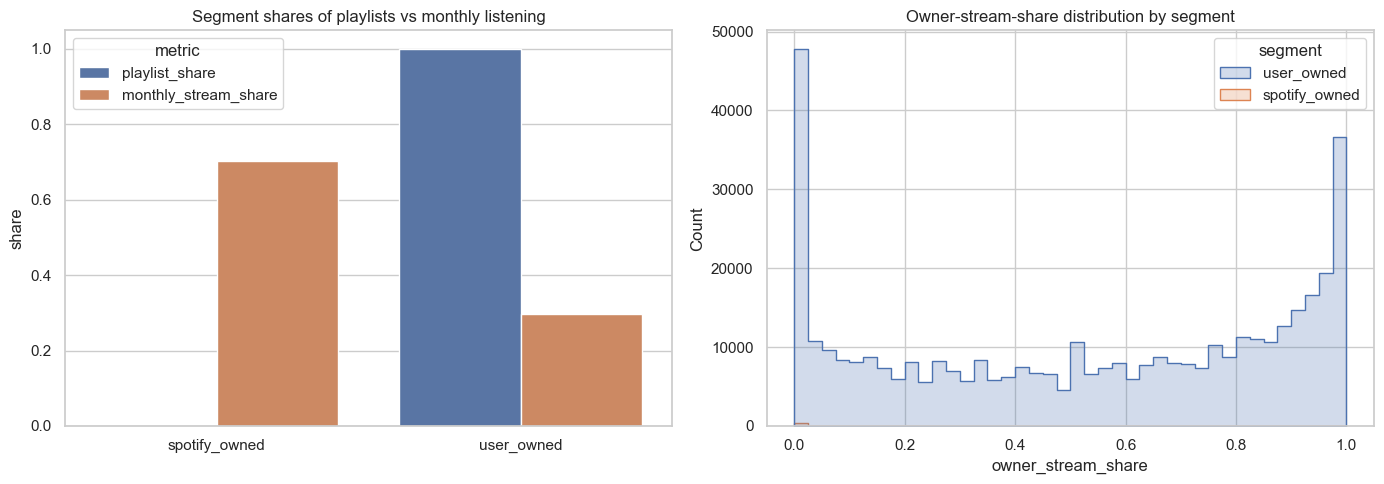

In [23]:
owner_dependence_summary = pd.DataFrame(
    {
        "metric": [
            "share_user_owned_playlists_with_owner_share_gt_50pct",
            "share_user_owned_playlists_with_owner_share_gt_90pct",
            "share_user_owned_playlists_with_non_owner_streams_eq_0",
            "median_user_owned_owner_stream_share",
            "median_user_owned_mau",
            "median_user_owned_users",
        ],
        "value": [
            (df.loc[df["segment"] == "user_owned", "owner_stream_share"] > 0.50).mean(),
            (df.loc[df["segment"] == "user_owned", "owner_stream_share"] > 0.90).mean(),
            (df.loc[df["segment"] == "user_owned", "non_owner_monthly_stream30s"] == 0).mean(),
            df.loc[df["segment"] == "user_owned", "owner_stream_share"].median(),
            df.loc[df["segment"] == "user_owned", "mau"].median(),
            df.loc[df["segment"] == "user_owned", "users"].median(),
        ],
    }
)
display(owner_dependence_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

share_plot = (
    segment_overview[["share_of_playlists", "share_of_monthly_stream30s"]]
    .rename(columns={
        "share_of_playlists": "playlist_share",
        "share_of_monthly_stream30s": "monthly_stream_share"
    })
    .reset_index()
    .melt(id_vars="segment", var_name="metric", value_name="share")
)

sns.barplot(data=share_plot, x="segment", y="share", hue="metric", ax=axes[0])
axes[0].set_title("Segment shares of playlists vs monthly listening")
axes[0].set_xlabel("")
axes[0].set_ylabel("share")

sns.histplot(
    data=df,
    x="owner_stream_share",
    hue="segment",
    bins=40,
    common_norm=False,
    element="step",
    ax=axes[1],
)
axes[1].set_title("Owner-stream-share distribution by segment")
axes[1].set_xlabel("owner_stream_share")

plt.tight_layout()


## 4. User-Owned Playlist Archetypes (Descriptive Only)

The user-owned segment is itself heterogeneous. This section creates a few **proxy archetypes** to make that heterogeneity easier to discuss.

These archetypes are **descriptive only**. Some of them depend partly on downstream behavior, so they should not be treated as causal groups in the core feature-success analysis.


In [24]:
user_df = df[df["segment"] == "user_owned"].copy()

user_df["archetype_personal_use_proxy"] = user_df["owner_stream_share"] > 0.90
user_df["archetype_broader_reach_proxy"] = user_df["non_owner_monthly_stream30s"] > 0
user_df["archetype_curator_like_proxy"] = user_df["owner_playlist_count"] >= 5
user_df["archetype_artist_discography_proxy"] = (
    (user_df["n_artists"] == 1) & (user_df["n_albums"] >= 2) & (user_df["n_tracks"] >= 15)
)

archetype_summary = pd.DataFrame(
    {
        "archetype": [
            "personal_use_proxy",
            "broader_reach_proxy",
            "curator_like_proxy",
            "artist_discography_proxy",
        ],
        "share_of_user_owned": [
            user_df["archetype_personal_use_proxy"].mean(),
            user_df["archetype_broader_reach_proxy"].mean(),
            user_df["archetype_curator_like_proxy"].mean(),
            user_df["archetype_artist_discography_proxy"].mean(),
        ],
        "median_non_owner_monthly_stream30s": [
            user_df.loc[user_df["archetype_personal_use_proxy"], "non_owner_monthly_stream30s"].median(),
            user_df.loc[user_df["archetype_broader_reach_proxy"], "non_owner_monthly_stream30s"].median(),
            user_df.loc[user_df["archetype_curator_like_proxy"], "non_owner_monthly_stream30s"].median(),
            user_df.loc[user_df["archetype_artist_discography_proxy"], "non_owner_monthly_stream30s"].median(),
        ],
        "median_owner_stream_share": [
            user_df.loc[user_df["archetype_personal_use_proxy"], "owner_stream_share"].median(),
            user_df.loc[user_df["archetype_broader_reach_proxy"], "owner_stream_share"].median(),
            user_df.loc[user_df["archetype_curator_like_proxy"], "owner_stream_share"].median(),
            user_df.loc[user_df["archetype_artist_discography_proxy"], "owner_stream_share"].median(),
        ],
    }
)

display(archetype_summary)


,archetype,share_of_user_owned,median_non_owner_monthly_stream30s,median_owner_stream_share
0,personal_use_proxy,0.2069,3.0000,0.9675
1,broader_reach_proxy,0.9662,22.0000,0.5393
2,curator_like_proxy,0.0578,24.0000,0.3023
3,artist_discography_proxy,0.0257,28.0000,0.4894


## 5. Define Success For The Main Analysis

The core analysis focuses on user-owned playlists and uses a **continuous** success metric.

### Primary metric
- `non_owner_monthly_stream30s`

### Why this choice?
- `monthly` is less noisy than daily counts
- `stream30s` is more meaningful than raw starts
- subtracting owner listening reduces inflation from purely personal playlists

### Important note
This is not the one true definition of success for every playlist. It is a deliberate **platform-facing lens** for comparing user-owned playlists in a mixed ecosystem.


,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
non_owner_monthly_stream30s,"417,085.0000",251.8577,"10,745.2824",0.0000,2.0000,6.0000,21.0000,64.0000,183.0000,"2,097.3200","5,098,545.0000"
monthly_stream30s,"417,085.0000",368.8694,"10,749.2285",2.0000,13.0000,32.0000,83.0000,215.0000,558.0000,"2,513.0000","5,098,585.0000"
owner_stream_share,"417,085.0000",0.5273,0.3491,0.0000,0.0129,0.1880,0.5652,0.8649,0.9692,1.0000,1.0000
n_tracks,"417,085.0000",194.8993,575.4880,1.0000,15.0000,34.0000,80.0000,185.0000,407.0000,"1,833.1600","79,984.0000"
n_artists,"417,085.0000",81.0731,126.9063,1.0000,1.0000,16.0000,44.0000,98.0000,191.0000,579.0000,"5,226.0000"
n_albums,"417,085.0000",85.2994,131.9215,1.0000,3.0000,17.0000,46.0000,103.0000,201.0000,607.0000,"6,397.0000"


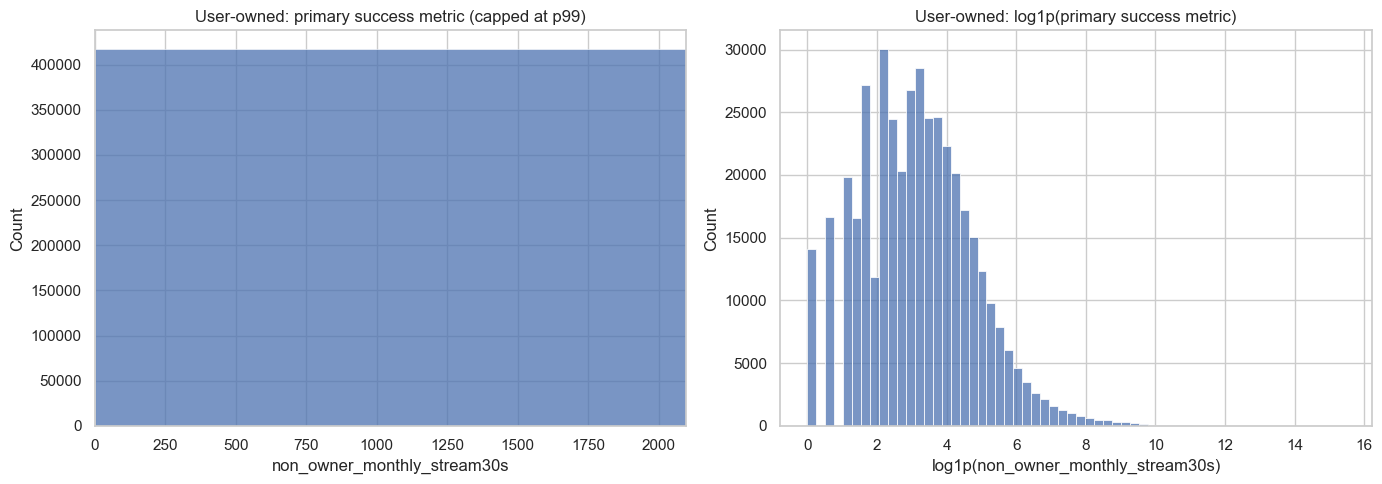

In [25]:
user_success_summary = user_df[
    [
        "non_owner_monthly_stream30s",
        "monthly_stream30s",
        "owner_stream_share",
        "n_tracks",
        "n_artists",
        "n_albums",
    ]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T

display(user_success_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_df["non_owner_monthly_stream30s"], bins=80, ax=axes[0])
axes[0].set_xlim(0, user_df["non_owner_monthly_stream30s"].quantile(0.99))
axes[0].set_title("User-owned: primary success metric (capped at p99)")
axes[0].set_xlabel("non_owner_monthly_stream30s")

sns.histplot(user_df["log_success"], bins=60, ax=axes[1])
axes[1].set_title("User-owned: log1p(primary success metric)")
axes[1].set_xlabel("log1p(non_owner_monthly_stream30s)")

plt.tight_layout()


## 6. Structural Correlates Of Success In User-Owned Playlists

This is the core descriptive analysis.

### Goal
Identify which **playlist features** are associated with higher success in user-owned playlists.

### Features included
- size / labeling: `n_tracks`, `n_title_tokens`
- recent update activity: `recent_track_change`
- diversity: `n_artists`, `n_albums`
- owner context: `owner_playlist_count`
- one-artist indicator: `one_artist`

Note: the raw field is `n_local_tracks`, but the assignment describes it as **change in number of tracks on playlist since yesterday**. The analysis below therefore uses the clearer alias `recent_track_change`.

### What this section does
1. Spearman screening for numeric / ordinal associations
2. Binned plots to show shape and nonlinearity


In [26]:
structural_features = [
    "n_tracks",
    "n_artists",
    "n_albums",
    "recent_track_change",
    "owner_playlist_count",
    "n_title_tokens",
    "one_artist",
]

structural_corr = screen_spearman(user_df, "log_success", structural_features)
display(structural_corr)


,feature,spearman_rho,p_value,n,p_adj_bh,significant_bh_5pct
0,n_tracks,0.2403,0.0000,417085,0.0000,True
2,n_albums,0.1909,0.0000,417085,0.0000,True
1,n_artists,0.1849,0.0000,417085,0.0000,True
6,one_artist,-0.1701,0.0000,417085,0.0000,True
5,n_title_tokens,0.1657,0.0000,417085,0.0000,True
4,owner_playlist_count,0.0649,0.0000,417085,0.0000,True
3,recent_track_change,0.0573,0.0000,417085,0.0000,True


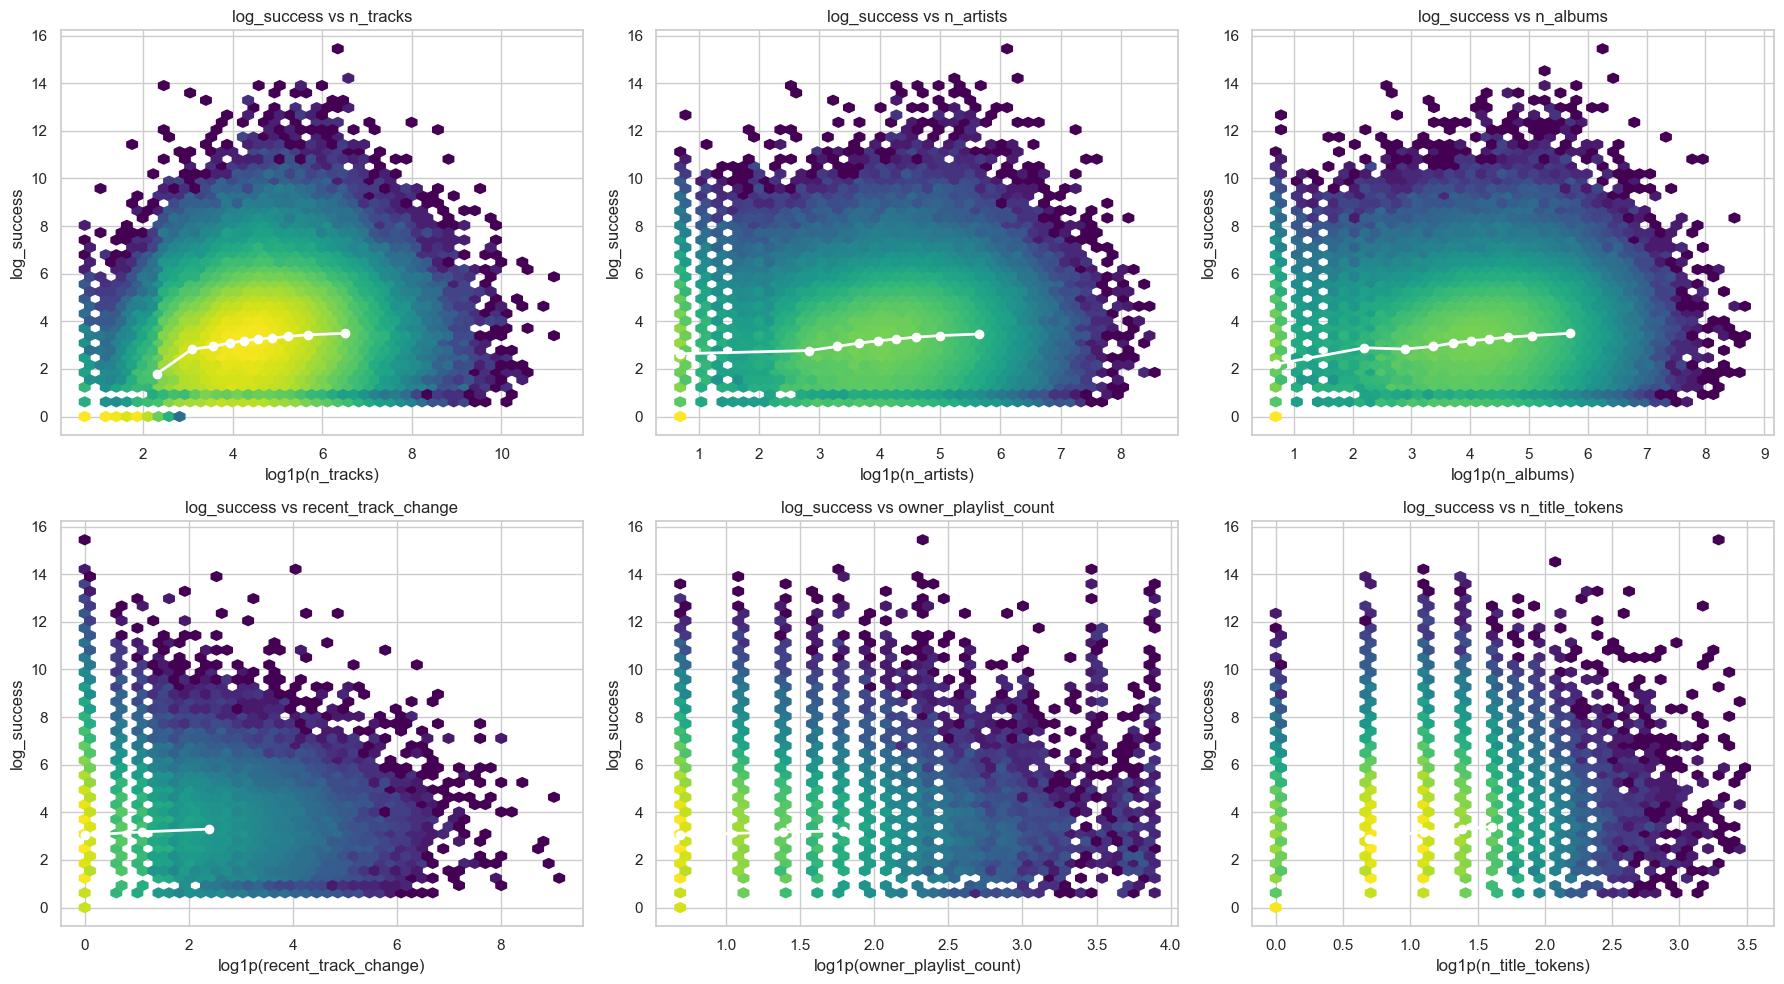

In [27]:
plot_features = ["n_tracks", "n_artists", "n_albums", "recent_track_change", "owner_playlist_count", "n_title_tokens"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feature in zip(axes.flat, plot_features):
    sub = user_df[[feature, "log_success"]].dropna()
    ax.hexbin(
        np.log1p(sub[feature]),
        sub["log_success"],
        gridsize=45,
        mincnt=1,
        bins="log",
        cmap="viridis",
    )

    summary = binned_relationship_summary(user_df, feature, "log_success", bins=10)
    ax.plot(
        np.log1p(summary["feature_median"]),
        summary["target_median"],
        color="white",
        marker="o",
        linewidth=2,
    )
    ax.set_title(f"log_success vs {feature}")
    ax.set_xlabel(f"log1p({feature})")
    ax.set_ylabel("log_success")

plt.tight_layout()


## 7. Content Summaries: Genre, Mood, And Title Tokens

These summaries are descriptive, not causal. They help answer whether certain themes appear more often among stronger user-owned playlists.

To keep noisy categories from dominating the view, the tables below require a minimum support threshold.


In [28]:
user_df["success_top_decile_user"] = (
    user_df["non_owner_monthly_stream30s"] >= user_df["non_owner_monthly_stream30s"].quantile(0.9)
).astype(int)

genre_summary = category_summary(
    user_df,
    column="genre_1",
    target="non_owner_monthly_stream30s",
    success_col="success_top_decile_user",
    min_count=1000,
    top_n=15,
)

mood_summary = category_summary(
    user_df,
    column="mood_1",
    target="non_owner_monthly_stream30s",
    success_col="success_top_decile_user",
    min_count=1000,
    top_n=15,
)

token_frame = (
    user_df[["playlist_uri", "non_owner_monthly_stream30s", "success_top_decile_user", "tokens"]]
    .explode("tokens")
    .dropna(subset=["tokens"])
    .rename(columns={"tokens": "token"})
)

token_summary = (
    token_frame.groupby("token")
    .agg(
        playlists=("playlist_uri", "nunique"),
        median_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "median"),
        success_rate=("success_top_decile_user", "mean"),
    )
    .query("playlists >= 1000")
    .sort_values(["success_rate", "playlists"], ascending=[False, False])
    .head(20)
)
token_summary["success_rate_lift"] = token_summary["success_rate"] / user_df["success_top_decile_user"].mean()

display(genre_summary)
display(mood_summary)
display(token_summary)


,playlists,median_target,mean_target,success_rate,success_rate_lift
genre_1,,,,,
R&B,15568,42.0000,547.9861,0.2343,2.3326
Spoken & Audio,1183,33.0000,349.6695,0.2012,2.0033
Children's,1713,32.0000,621.3689,0.2043,2.0345
New Age,2262,28.0000,208.8170,0.1667,1.6596
Traditional,1605,28.0000,562.0361,0.1788,1.7805
Religious,21935,25.0000,261.6066,0.1143,1.1381
Country & Folk,14551,25.0000,244.7547,0.1126,1.1216
Classical,4107,25.0000,165.9128,0.1210,1.2050
Blues,3426,25.0000,302.2957,0.1442,1.4358


,playlists,median_target,mean_target,success_rate,success_rate_lift
mood_1,,,,,
Lively,10686,34.0000,370.4882,0.1975,1.9671
Other,1751,31.0000,379.4460,0.1947,1.9392
Tender,3403,30.0000,371.1704,0.1784,1.7761
Romantic,9771,29.0000,616.1763,0.1759,1.7518
Peaceful,2413,27.0000,271.6482,0.1670,1.6630
Upbeat,16732,26.0000,379.4727,0.1171,1.1664
Stirring,1974,25.0000,145.0957,0.1120,1.1148
Sophisticated,7899,24.0000,242.6519,0.1420,1.4144
Empowering,34204,22.0000,271.4784,0.1076,1.0710


,playlists,median_non_owner_monthly_stream30s,success_rate,success_rate_lift
token,,,,
soundtrack,1235,42.5000,0.2904,2.8916
top,1779,41.5000,0.2486,2.4754
hits,1899,40.5000,0.2387,2.3773
christian,1178,41.0000,0.2284,2.2743
sleep,1047,35.0000,0.2144,2.1350
jazz,1131,31.0000,0.1948,1.9394
pop,2021,29.0000,0.1836,1.8282
best,4258,30.0000,0.1673,1.6656
classic,1306,30.0000,0.1533,1.5266


## 8. Multivariable Models: How Much Variation Do Playlist Features Explain?

The goal here is not to estimate causal effects. The goal is to quantify how much of the variation in the working success metric is captured by the observed playlist features.

### Models
- **Structural model**: size, diversity, owner history, and one-artist flag
- **Structural + content model**: add grouped genre and mood indicators
- **Alternative-outcome model**: repeat the structural model with `monthly_stream30s` as a sensitivity check

These models answer:
- which features remain associated with success when considered together?
- how much does content add beyond structure?
- are the conclusions sensitive to the owner-adjusted outcome?


In [29]:
user_model_df = user_df.copy()
spotify_model_df = df[df["segment"] == "spotify_owned"].copy()

for frame in [user_model_df, spotify_model_df]:
    frame["genre_1_grouped"] = top_category_group(frame["genre_1"], top_n=10)
    frame["mood_1_grouped"] = top_category_group(frame["mood_1"], top_n=10)

for frame in [user_model_df, spotify_model_df]:
    for col in ["n_tracks", "n_artists", "n_albums", "recent_track_change", "owner_playlist_count", "n_title_tokens"]:
        frame[f"log_{col}"] = np.log1p(frame[col])

vif_input = user_model_df[
    [
        "log_n_tracks",
        "log_n_artists",
        "log_n_albums",
        "log_recent_track_change",
        "log_owner_playlist_count",
        "log_n_title_tokens",
    ]
].dropna().copy()
vif_input.insert(0, "const", 1.0)

vif_rows = []
for idx, column in enumerate(vif_input.columns):
    if column == "const":
        continue
    vif_rows.append({"feature": column, "vif": variance_inflation_factor(vif_input.values, idx)})
vif_table = pd.DataFrame(vif_rows)
display(vif_table)


,feature,vif
0,log_n_tracks,2.9420
1,log_n_artists,5.6473
2,log_n_albums,6.8540
3,log_recent_track_change,1.1533
4,log_owner_playlist_count,1.0098
5,log_n_title_tokens,1.0282


,model,nobs,r2,adj_r2,model_pvalue
0,user_owned_structural,"417,085.0000",0.1381,0.1381,0.0000
1,user_owned_structural_plus_content,"417,085.0000",0.1479,0.1478,0.0000
2,user_owned_structural_alt_outcome,"417,085.0000",0.0993,0.0993,0.0000
3,spotify_owned_structural_exploratory,399.0000,0.1802,0.1676,0.0000


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,"417,077.0000","964,398.5602",0.0000,NaN,NaN,NaN
1,"417,057.0000","953,485.9823",20.0000,"10,912.5779",238.6594,0.0000


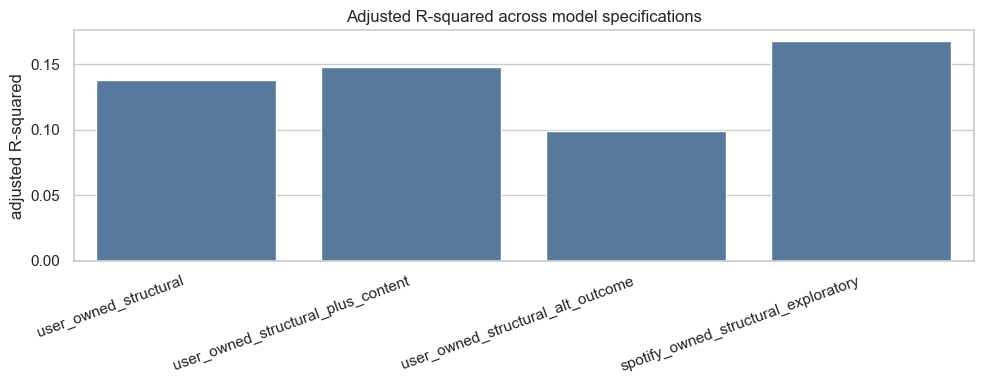

In [30]:
structural_formula = (
    "log_success ~ log_n_tracks + log_n_artists + log_n_albums + "
    "log_recent_track_change + log_owner_playlist_count + log_n_title_tokens + one_artist"
)

content_formula = structural_formula + " + C(genre_1_grouped) + C(mood_1_grouped)"
alt_outcome_formula = structural_formula.replace("log_success", "log_monthly_stream30s")
spotify_formula = (
    "log_success ~ log_n_tracks + log_n_artists + log_n_albums + "
    "log_recent_track_change + log_n_title_tokens + one_artist"
)

model_structural = smf.ols(structural_formula, data=user_model_df).fit()
model_content = smf.ols(content_formula, data=user_model_df).fit()
model_alt_outcome = smf.ols(alt_outcome_formula, data=user_model_df).fit()
model_spotify = smf.ols(spotify_formula, data=spotify_model_df).fit()

model_fit_summary = pd.DataFrame(
    [
        {
            "model": "user_owned_structural",
            "nobs": model_structural.nobs,
            "r2": model_structural.rsquared,
            "adj_r2": model_structural.rsquared_adj,
            "model_pvalue": model_structural.f_pvalue,
        },
        {
            "model": "user_owned_structural_plus_content",
            "nobs": model_content.nobs,
            "r2": model_content.rsquared,
            "adj_r2": model_content.rsquared_adj,
            "model_pvalue": model_content.f_pvalue,
        },
        {
            "model": "user_owned_structural_alt_outcome",
            "nobs": model_alt_outcome.nobs,
            "r2": model_alt_outcome.rsquared,
            "adj_r2": model_alt_outcome.rsquared_adj,
            "model_pvalue": model_alt_outcome.f_pvalue,
        },
        {
            "model": "spotify_owned_structural_exploratory",
            "nobs": model_spotify.nobs,
            "r2": model_spotify.rsquared,
            "adj_r2": model_spotify.rsquared_adj,
            "model_pvalue": model_spotify.f_pvalue,
        },
    ]
)

content_vs_structural = anova_lm(model_structural, model_content)

display(model_fit_summary)
display(content_vs_structural)

plt.figure(figsize=(10, 4))
sns.barplot(data=model_fit_summary, x="model", y="adj_r2", color="#4C78A8")
plt.xticks(rotation=20, ha="right")
plt.title("Adjusted R-squared across model specifications")
plt.xlabel("")
plt.ylabel("adjusted R-squared")
plt.tight_layout()


In [31]:
structural_coef = coefficient_table(model_structural)
content_coef = coefficient_table(model_content)
spotify_coef = coefficient_table(model_spotify)

display(structural_coef)
display(content_coef.head(30))
display(spotify_coef)


,term,coef,p_value,p_adj_bh
0,Intercept,1.1255,0.0000,0.0000
1,log_n_tracks,0.4348,0.0000,0.0000
2,log_n_artists,-0.1865,0.0000,0.0000
5,log_owner_playlist_count,0.3100,0.0000,0.0000
6,log_n_title_tokens,0.6091,0.0000,0.0000
7,one_artist,-0.8258,0.0000,0.0000
4,log_recent_track_change,-0.0675,0.0000,0.0000
3,log_n_albums,0.0141,0.0012,0.0012


,term,coef,p_value,p_adj_bh
0,Intercept,1.1310,0.0000,0.0000
25,log_owner_playlist_count,0.3083,0.0000,0.0000
21,log_n_tracks,0.4157,0.0000,0.0000
26,log_n_title_tokens,0.5904,0.0000,0.0000
27,one_artist,-0.7591,0.0000,0.0000
22,log_n_artists,-0.1685,0.0000,0.0000
7,C(genre_1_grouped)[T.R&B],0.5503,0.0000,0.0000
24,log_recent_track_change,-0.0620,0.0000,0.0000
10,C(genre_1_grouped)[T.Rock],-0.1565,0.0000,0.0000
12,C(mood_1_grouped)[T.Defiant],-0.1378,0.0000,0.0000


,term,coef,p_value,p_adj_bh
0,Intercept,4.5461,0.0000,0.0000
6,one_artist,5.6582,0.0000,0.0000
5,log_n_title_tokens,0.7166,0.0358,0.0836
3,log_n_albums,0.8203,0.1018,0.1782
2,log_n_artists,0.7400,0.1537,0.2152
1,log_n_tracks,0.0631,0.8038,0.8038
4,log_recent_track_change,-0.1733,0.7574,0.8038


## 9. Top-Decile View For Communication

This is a **secondary** view. It makes the continuous analysis easier to communicate, but it does not replace it.

The question here is:
- what do the strongest user-owned playlists look like relative to the rest?


In [32]:
top_decile_feature_gap = []
for feature in ["n_tracks", "n_artists", "n_albums", "recent_track_change", "owner_playlist_count", "n_title_tokens", "one_artist"]:
    success_values = user_df.loc[user_df["success_top_decile_user"] == 1, feature]
    rest_values = user_df.loc[user_df["success_top_decile_user"] == 0, feature]
    top_decile_feature_gap.append(
        {
            "feature": feature,
            "top_decile_median": success_values.median(),
            "rest_median": rest_values.median(),
            "median_ratio": success_values.median() / rest_values.median() if rest_values.median() not in [0, np.nan] else np.nan,
            "top_decile_mean": success_values.mean(),
            "rest_mean": rest_values.mean(),
        }
    )

top_decile_feature_gap = pd.DataFrame(top_decile_feature_gap)
display(top_decile_feature_gap)


,feature,top_decile_median,rest_median,median_ratio,top_decile_mean,rest_mean
0,n_tracks,123.0000,76.0000,1.6184,287.6243,184.5475
1,n_artists,61.0000,42.0000,1.4524,107.3599,78.1385
2,n_albums,63.0000,45.0000,1.4000,112.9976,82.2072
3,recent_track_change,0.0000,0.0000,NaN,4.2346,2.8427
4,owner_playlist_count,1.0000,1.0000,1.0000,2.0671,1.8302
5,n_title_tokens,2.0000,2.0000,1.0000,2.1691,1.7078
6,one_artist,0.0000,0.0000,NaN,0.0752,0.1061


## 10. Spotify-Owned Playlists As A Contrast Group

Spotify-owned playlists are not the main inferential population in this notebook. They are a contrast group.

The point of this section is to show:
- how different they are from user-owned playlists
- whether the same structural features even seem to matter there


In [33]:
spotify_df = df[df["segment"] == "spotify_owned"].copy()

spotify_corr = screen_spearman(
    spotify_df,
    "log_success",
    ["n_tracks", "n_artists", "n_albums", "recent_track_change", "n_title_tokens", "one_artist"],
)

spotify_contrast = pd.DataFrame(
    {
        "metric": [
            "playlists",
            "median_monthly_stream30s",
            "median_non_owner_monthly_stream30s",
            "median_owner_stream_share",
            "median_n_tracks",
            "median_n_artists",
            "median_n_albums",
        ],
        "spotify_owned": [
            len(spotify_df),
            spotify_df["monthly_stream30s"].median(),
            spotify_df["non_owner_monthly_stream30s"].median(),
            spotify_df["owner_stream_share"].median(),
            spotify_df["n_tracks"].median(),
            spotify_df["n_artists"].median(),
            spotify_df["n_albums"].median(),
        ],
        "user_owned": [
            len(user_df),
            user_df["monthly_stream30s"].median(),
            user_df["non_owner_monthly_stream30s"].median(),
            user_df["owner_stream_share"].median(),
            user_df["n_tracks"].median(),
            user_df["n_artists"].median(),
            user_df["n_albums"].median(),
        ],
    }
)

display(spotify_contrast)
display(spotify_corr)


,metric,spotify_owned,user_owned
0,playlists,399.0000,"417,085.0000"
1,median_monthly_stream30s,"154,812.0000",83.0000
2,median_non_owner_monthly_stream30s,"154,812.0000",21.0000
3,median_owner_stream_share,0.0000,0.5652
4,median_n_tracks,59.0000,80.0000
5,median_n_artists,47.0000,44.0000
6,median_n_albums,49.0000,46.0000


,feature,spearman_rho,p_value,n,p_adj_bh,significant_bh_5pct
0,n_tracks,0.3998,0.0000,399,0.0000,True
2,n_albums,0.3886,0.0000,399,0.0000,True
1,n_artists,0.3790,0.0000,399,0.0000,True
5,one_artist,0.0762,0.1287,399,0.1930,False
3,recent_track_change,-0.0298,0.5529,399,0.6635,False
4,n_title_tokens,0.0129,0.7972,399,0.7972,False


## 11. Review And Limitations

This final section turns the notebook into presentation-ready talking points.


In [34]:
strongest_user_corr = structural_corr.iloc[0]

print("Main framing")
print("- This is a segmented, descriptive analysis of playlist success.")
print("- The main analytical population is user-owned playlists.")
print()

print("Why segmentation matters")
print(
    f"- Spotify-owned playlists are {segment_overview.loc['spotify_owned', 'share_of_playlists']:.3%} of playlists "
    f"but {segment_overview.loc['spotify_owned', 'share_of_monthly_stream30s']:.3%} of monthly_stream30s."
)
print(
    f"- In user-owned playlists, the median owner_stream_share is "
    f"{segment_overview.loc['user_owned', 'median_owner_stream_share']:.3f}."
)
print()

print("Main user-owned success metric")
print("- Primary metric: non_owner_monthly_stream30s")
print("- Continuous model target: log1p(non_owner_monthly_stream30s)")
print()

print("Strongest structural correlation in user-owned playlists")
print(
    f"- {strongest_user_corr['feature']} with Spearman rho = {strongest_user_corr['spearman_rho']:.3f} "
    f"(BH-adjusted significant: {bool(strongest_user_corr['significant_bh_5pct'])})"
)
print()

print("Variation explained")
print(
    f"- Structural model adjusted R-squared: {model_structural.rsquared_adj:.3f}"
)
print(
    f"- Structural + content model adjusted R-squared: {model_content.rsquared_adj:.3f}"
)
print(
    f"- Structural model with alternative outcome adjusted R-squared: {model_alt_outcome.rsquared_adj:.3f}"
)
print(
    f"- Exploratory Spotify-owned structural model adjusted R-squared: {model_spotify.rsquared_adj:.3f}"
)
print()

print("Interpretation")
print("- Playlist structure explains a meaningful but limited share of variation in user-owned success.")
print("- Genre and mood add incremental signal beyond structure.")
print("- Spotify-owned playlists look structurally and behaviorally different enough that pooled analysis would be misleading.")
print()

print("Limitations")
print("- Cross-sectional data support correlational claims, not causal claims.")
print("- Spotify-owned playlists likely have different exposure mechanisms than user-owned playlists.")
print("- Some user-owned archetypes are defined using downstream behavior and are descriptive only.")


Main framing
- This is a segmented, descriptive analysis of playlist success.
- The main analytical population is user-owned playlists.

Why segmentation matters
- Spotify-owned playlists are 0.096% of playlists but 70.385% of monthly_stream30s.
- In user-owned playlists, the median owner_stream_share is 0.565.

Main user-owned success metric
- Primary metric: non_owner_monthly_stream30s
- Continuous model target: log1p(non_owner_monthly_stream30s)

Strongest structural correlation in user-owned playlists
- n_tracks with Spearman rho = 0.240 (BH-adjusted significant: True)

Variation explained
- Structural model adjusted R-squared: 0.138
- Structural + content model adjusted R-squared: 0.148
- Structural model with alternative outcome adjusted R-squared: 0.099
- Exploratory Spotify-owned structural model adjusted R-squared: 0.168

Interpretation
- Playlist structure explains a meaningful but limited share of variation in user-owned success.
- Genre and mood add incremental signal beyon